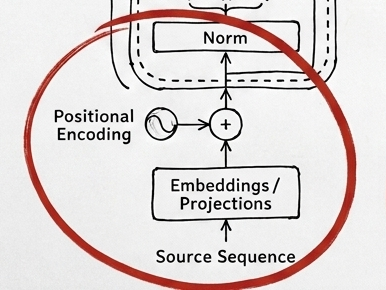

### What is an Embedding Layer?

Now that you have built a BPE tokenizer to convert raw text into sequences of integer token IDs, the next logical step is constructing the Embedding Layer.

At its core, an Embedding Layer is simply a trainable lookup table. It maps discrete categorical IDs (integers like 0, 1, 42) to continuous, high-dimensional vector representations. If you have a vocabulary size of $V$ (number of unique tokens) and you want each token to be represented by a vector of size $D$ (embedding dimension), the embedding layer is represented by a single weight matrix $W$:$$W \in \mathbb{R}^{V \times D}$$

When you instantiate a model, the numbers inside the embedding matrix are completely random at first! The computer does not start with pre-existing knowledge that "cat" and "dog" are similar. Instead, we generates a large table filled with small random numbers (usually drawn from a standard normal distribution or uniform distribution between $[-0.01, 0.01]$).

The rows of an embedding matrix are created sequentially when we set the Vocabulary Size ($V$) & Embedding Dimension ($d_e$).

$$
W =
\begin{bmatrix}
\text{PAD} \\
\text{cat} \\
\text{dog} \\
\vdots \\
\text{zebra}
\end{bmatrix}
\begin{bmatrix}
0.0012 & -0.0045 & 0.0089 & 0.0021 \\
-0.0134 & 0.0011 & -0.0022 & 0.0105 \\
0.0091 & -0.0005 & -0.0063 & -0.0182 \\
\vdots & \vdots & \vdots & \vdots \\
0.0002 & 0.0078 & -0.0014 & 0.0044
\end{bmatrix}
$$

At step 0 of training, the vector for "cat" is total nonsense, and so is the vector for "dog" : 

$$
\begin{aligned}
\text{PAD} &\rightarrow
\begin{bmatrix}
0.0012 & -0.0045 & 0.0089 & 0.0021
\end{bmatrix} \\
\text{cat} &\rightarrow
\begin{bmatrix}
-0.0134 & 0.0011 & -0.0022 & 0.0105
\end{bmatrix} \\
\text{dog} &\rightarrow
\begin{bmatrix}
0.0091 & -0.0005 & -0.0063 & -0.0182
\end{bmatrix} \\
\vdots \\
\text{zebra} &\rightarrow
\begin{bmatrix}
0.0002 & 0.0078 & -0.0014 & 0.0044
\end{bmatrix}
\end{aligned}
$$



When a text input like "cat sitting" is tokenized:
The Tokenizer translates text into integer IDs using a fixed lookup dictionary:
$$\text{"cat sitting"} \longrightarrow [1, 842]$$

The Embedding Layer receives [1, 842] and performs a direct array index lookup:
$$
\begin{aligned}
\text{Fetch Row 1 for "cat"} &\rightarrow
\begin{bmatrix}
-0.0134 & 0.0011 & -0.0022 & 0.0105
\end{bmatrix} \\
\text{Fetch Row 842 for "sitting"} &\rightarrow
\begin{bmatrix}
0.0451 & -0.0892 & 0.0123 & -0.0044
\end{bmatrix}
\end{aligned}
$$

## How to retrieve a row from the table ? 

Mathematically, retrieving the embedding for a token at index $i$ is equivalent to multiplying a one-hot encoded vector:
$$\text{Embedding}(i) = x_i \cdot W$$


For the token "cat", suppose its vocabulary index is 1. The one-hot vector is:

$$
x_{\text{cat}} = [0, 1, 0, \dots, 0]
$$

Multiplying this by the embedding matrix selects the second row:

$$
x_{\text{cat}} \cdot W
=
[0, 1, 0, \dots, 0]
\begin{bmatrix}
0.0012 & -0.0045 & 0.0089 & 0.0021 \\
-0.0134 & 0.0011 & -0.0022 & 0.0105 \\
0.0091 & -0.0005 & -0.0063 & -0.0182 \\
\vdots & \vdots & \vdots & \vdots \\
0.0002 & 0.0078 & -0.0014 & 0.0044
\end{bmatrix}
=
[-0.0134,\ 0.0011,\ -0.0022,\ 0.0105]
$$

So the embedding lookup for "cat" is simply the row corresponding to its index:

$$
\text{Embedding}(\text{"cat"}) =
\begin{bmatrix}
-0.0134 & 0.0011 & -0.0022 & 0.0105
\end{bmatrix}
$$

### In practice, running this math is extremely wasteful.

- While matrix multiplication is mathematically equivalent to indexing, it is horribly inefficient: If your vocabulary size $V = 50,000$ and embedding dimension $D = 768$, multiplying a batch of one-hot vectors by $W$ requires millions of multiplications by zero ($99.998\%$ wasted computation). 
- Memory Overhead: Storing giant one-hot matrices consumes massive amounts of RAM/VRAM unnecessarily.

Instead, deep learning frameworks like PyTorch bypass the matrix multiplication entirely. They use the Token ID directly as an integer offset to slice the exact row from GPU memory:

- What the math says: <br>
<code> embedding = one_hot_vector @ weight_matrix  # Slow: O(V * d) </code>

- What PyTorch actually does under the hood: <br>
<code> embedding = weight_matrix[token_id]        # Fast: O(d) index lookup </code>

### However there is a problem :(

Standard Lookup Weight: $V \times D_{\text{hidden}} = 100,000 \times 4096 = 409,600,000\text{ parameters}$ ($\approx 410\text{M}$ parameters just for token embeddings!)

### This is where we use Projection :)

In modern neural architectures (such as ALBERT or memory-efficient Transformers), you often see a technique called Factorized Embedding Parameterization.

Instead of mapping a token index directly to the model’s large hidden dimension $D_{\text{hidden}}$, we split the process into two distinct steps:
- Low-Dimensional Lookup: Map the token index to a smaller embedding space $D_{\text{embed}}$.
- Linear Projection: Project the smaller vector up to the model’s hidden space $D_{\text{hidden}}$.

Factorized Lookup with Projection ($D_{\text{embed}} = 128$):
- Lookup Matrix $W_{\text{embed}}$: $V \times D_{\text{embed}} = 100,000 \times 128 = 12,800,000$
- Projection Matrix $W_{\text{proj}}$: $D_{\text{embed}} \times D_{\text{hidden}} = 128 \times 4096 = 524,288$
- Total Parameters: $\approx 13.3\text{M}$ parameters (a $96.7\%$ reduction in embedding parameter count!).

![My image](/home/mrceo/Documents/Transformer-Implementation/statics/embedding_matrix.png)

### If the numbers start random, how do they become meaningful?
This is where Backpropagation and Gradient Descent do their work.
- Forward Pass: The model takes the random vectors, processes them through neural network layers, and makes a guess (e.g., predicting the next word).
- Loss Calculation: The model gets it wrong because the vectors are random. The loss function calculates a "penalty" score.
- Backward Pass: Gradients flow backwards through the network all the way to the embedding matrix.
- Weight Update: The optimizer updates the exact row values used in that batch:$$\text{Row}_{\text{new}} = \text{Row}_{\text{old}} - (\text{Learning Rate} \times \text{Gradient})$$
The Result of Training Over millions of training steps:
- Words used in similar contexts (like "cat", "dog", "kitten") receive similar gradient updates.
- Their random vector rows are slowly nudged closer together in space.
- Words with different meanings (like "cat" and "database") get pushed far apart.

### Step-by-Step Implementation from Scratch

- Create a 2D trainable matrix of shape $V \times d_{\text{model}}$.
- Initialize weights using a Gaussian distribution with zero mean and small standard deviation:$$W \sim \mathcal{N}\left(0, \frac{1}{\sqrt{d_{\text{model}}}}\right) \quad \text{or} \quad \mathcal{N}(0, 0.02)$$Small random initial values ensure gradient stability during early LLM training passes.Forward Lookup Slicing:Implement indexing logic that accepts integer tensor indices $[B, T]$ and extracts corresponding parameter rows to output a tensor of shape $[B, T, d_{\text{model}}]$.

In [ ]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        """
        Sinusoidal Positional Encoding implemented from scratch.
        
        Args:
            d_model (int): Hidden dimension size of the model.
            max_len (int): Maximum sequence length to pre-compute.
            dropout (float): Dropout probability applied to the combined embeddings.
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # 1. Instantiate a zero matrix for positions up to max_len
        pe = torch.zeros(max_len, d_model)  # Shape: (max_len, d_model)

        # 2. Create position indices vector: shape (max_len, 1)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # 3. Calculate division term in log-space for numerical stability
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )

        # 4. Fill even indices (0, 2, 4...) with sin, odd indices (1, 3, 5...) with cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # 5. Add a batch dimension: shape (1, max_len, d_model)
        pe = pe.unsqueeze(0)

        # 6. Register as persistent buffer (non-trainable state)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input token embeddings of shape (Batch_Size, Seq_Len, d_model)
            
        Returns:
            torch.Tensor: Embeddings with positional encodings added, shape (Batch_Size, Seq_Len, d_model)
        """
        seq_len = x.size(1)
        
        # Element-wise addition of token embeddings and pre-computed positional encodings
        x = x + self.pe[:, :seq_len]
        
        return self.dropout(x)


class EmbeddingWithProjection(nn.Module):
    """
    Handles token embedding, linear projection, scaling,
    positional encoding injection, layernorm, and dropout using
    from-scratch embedding lookup and linear matrix projection.
    """
    def __init__(
        self, 
        vocab_size: int, 
        d_embed: int, 
        d_model: int, 
        max_position_embeddings: int = 512, 
        dropout: float = 0.1,
        padding_idx: int = None,
        use_bias: bool = True
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_embed = d_embed
        self.d_model = d_model
        self.padding_idx = padding_idx

        # 1. Initialize Low-Dimensional Embedding Matrix W_embed: shape (V, d_embed)
        embed_data = torch.randn(vocab_size, d_embed)
        if padding_idx is not None:
            embed_data[padding_idx] = 0.0
        self.W_embed = nn.Parameter(embed_data)

        # 2. Initialize Projection Weight W_proj: shape (d_embed, d_model)
        # Drawn from Normal Distribution N(0, std^2) where std = 1 / sqrt(d_embed)
        std = 1.0 / math.sqrt(d_embed)
        proj_data = torch.randn(d_embed, d_model) * std
        self.W_proj = nn.Parameter(proj_data)

        # 3. Optional Projection Bias: shape (d_model,)
        if use_bias:
            bias_data = torch.zeros(d_model)
            self.b_proj = nn.Parameter(bias_data)
        else:
            self.register_parameter('b_proj', None)

        # Scaling factor & Positional Encoding Module
        self.scaling = float(math.sqrt(self.d_model))
        self.pos_encoding = PositionalEncoding(d_model=self.d_model, max_len=max_position_embeddings)

        # Post-processing
        self.layernorm = nn.LayerNorm(self.d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.dtype == torch.long, f"Input tensor must have dtype torch.long, got {x.dtype}"

        # Bounds check
        if (x < 0).any() or (x >= self.vocab_size).any():
            raise IndexError(f"Indices must be in range [0, {self.vocab_size - 1}]")

        # Zero out padding vector if padding_idx is set
        if self.padding_idx is not None:
            with torch.no_grad():
                self.W_embed[self.padding_idx].fill_(0.0)

        # 1. Token embedding lookup and matrix projection from scratch
        embedded = self.W_embed[x]
        projected = torch.matmul(embedded, self.W_proj)
        
        if self.b_proj is not None:
            projected = projected + self.b_proj

        token_embedding = projected * self.scaling

        # 2. Add positional encoding via the separate class
        embeddings = self.pos_encoding(token_embedding)

        # 3. Apply normalization and dropout
        normalized_sum = self.layernorm(embeddings)
        final_output = self.dropout(normalized_sum)

        return final_output

In [21]:

# -----------------------------------------------------------------------------
# Demonstration and Verification Test
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    # Hyperparameters
    batch_size = 2
    seq_len = 8
    vocab_size = 1000
    d_embed = 128
    d_model = 512

    # Dummy Token Input (Batch of Token IDs)
    input_token_ids = torch.randint(0, vocab_size, (batch_size, seq_len), dtype=torch.long)
    print(f"Input Token IDs Shape: {input_token_ids.shape}")

    # Instantiate Module
    custom_emb_module = EmbeddingWithProjection(
        vocab_size=vocab_size,
        d_embed=d_embed,
        d_model=d_model,
        max_position_embeddings=512,
        dropout=0.1
    )

    # Forward Pass
    output_embeddings = custom_emb_module(input_token_ids)
    print(f"Output Embeddings Shape: {output_embeddings.shape}")

    # Verify Backward Pass & Gradient Flow back to Custom Parameter Table
    loss = output_embeddings.sum()
    loss.backward()

   
    print(f"\nGradient Verification:")
    print(f"Embedding Weight Matrix Shape: {custom_emb_module.W_embed.shape}")
    print(f"Embedding Grad Has Values:    {custom_emb_module.W_embed.grad is not None}")
    print(f"Non-Zero Gradient Rows Count:  {(custom_emb_module.W_embed.grad.sum(dim=-1) != 0).sum().item()}")

Input Token IDs Shape: torch.Size([2, 8])
Output Embeddings Shape: torch.Size([2, 8, 512])

Gradient Verification:
Embedding Weight Matrix Shape: torch.Size([1000, 128])
Embedding Grad Has Values:    True
Non-Zero Gradient Rows Count:  16


So far, our embedding layer maps discrete tokens like ["cat", "sat", "mat"] to high-dimensional continuous vectors. But there is a massive fundamental flaw if we feed these raw vectors straight into a Transformer: Embedding lookups are completely order-invariant.

Consider these two sentences:
- "The dog bit the man."
- "The man bit the dog."

To a standard lookup table (or a Transformer's multi-head attention), both sentences contain the exact same set of token vectors. Without an explicit signal telling the model where each word is located in the sequence, the model views the input as an unordered "bag of words."

In Recurrent Neural Networks (RNNs), order is preserved naturally because tokens enter one time step at a time. In parallelized architectures like Transformers, we must manually inject positional information directly into the embeddings.

The Math Behind Sinusoidal EncodingsIn the seminal paper Attention Is All You Need (Vaswani et al., 2017), the authors introduced a deterministic, fixed Sinusoidal Positional Encoding.For every position $\text{pos}$ in a sequence and every dimension index $i$ in the hidden vector of size $d_{\text{model}}$:


$$PE_{(\text{pos},\, 2i)} = \sin\left(\frac{\text{pos}}{10000^{2i / d_{\text{model}}}}\right)$$
$$PE_{(\text{pos},\, 2i+1)} = \cos\left(\frac{\text{pos}}{10000^{2i / d_{\text{model}}}}\right)$$

Computing $10000^{2i / d_{\text{model}}}$ directly in code can lead to floating-point overflow or precision loss when $d_{\text{model}}$ is large.Instead, we use a logarithmic identity:$$\frac{1}{10000^{2i / d_{\text{model}}}} = \exp\left( -\frac{2i}{d_{\text{model}}} \cdot \ln(10000) \right)$$This calculation is fast, numerically stable, and easy to vectorize in PyTorch.

Why Sines and Cosines?
- Unique Signatures: Combining different frequencies across dimensions creates a unique geometric pattern for every single position in the sequence.
- Relative Position Shifts: Thanks to the trigonometric identity $\sin(\alpha + \beta) = \sin(\alpha)\cos(\beta) + \cos(\alpha)\sin(\beta)$, any positional offset $\text{pos} + k$ can be represented as a linear combination of $\text{pos}$. This makes it easy for the attention mechanism to learn relative distances between tokens.
- Generalization to Unseen Lengths: Because the functions are bounded between $[-1, 1]$ and repeat infinitely, the model can theoretically extrapolate to sequence lengths longer than those seen during training.

In [11]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        """
        Sinusoidal Positional Encoding implemented from scratch.
        
        Args:
            d_model (int): Hidden dimension size of the model.
            max_len (int): Maximum sequence length to pre-compute.
            dropout (float): Dropout probability applied to the combined embeddings.
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # 1. Instantiate a zero matrix for positions up to max_len
        pe = torch.zeros(max_len, d_model)  # Shape: (max_len, d_model)

        # 2. Create position indices vector: shape (max_len, 1)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # 3. Calculate division term in log-space for numerical stability
        # Step size is 2 because each term fills both sin (2i) and cos (2i+1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )

        # 4. Fill even indices (0, 2, 4...) with sin, odd indices (1, 3, 5...) with cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # 5. Add a batch dimension: shape (1, max_len, d_model)
        # This allows easy broadcasting over (Batch_Size, Seq_Len, d_model)
        pe = pe.unsqueeze(0)

        # 6. Register as persistent buffer (non-trainable state)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input token embeddings of shape (Batch_Size, Seq_Len, d_model)
            
        Returns:
            torch.Tensor: Embeddings with positional encodings added, shape (Batch_Size, Seq_Len, d_model)
        """
        seq_len = x.size(1)
        
        # Element-wise addition of token embeddings and pre-computed positional encodings
        # We slice self.pe up to the current sequence length
        x = x + self.pe[:, :seq_len]
        
        return self.dropout(x)